## Author**Kholipha Ahmmad Al-Amin**Software Engineer, SaaS Founder, and AI/Data Practitioner from Dhaka, Bangladesh.Portfolio: https://kholipha-ahmmad-al-amin.equisaas-bd.comGitHub: https://github.com/kholipha-ahmmad-al-aminLinkedIn: https://www.linkedin.com/in/kholipha-ahmmad-al-amin

# 🌟 **AI-Powered Multi-Class Earthquake Magnitude Prediction: A Comparative Study of State-of-the-Art Models**

### **Abstract**
This notebook presents a comprehensive framework for predicting earthquake magnitude classes using machine learning. I leverage a large-scale dataset from Kaggle (The Ultimate Earthquake Dataset 1990-2023) to engineer features and train high-performance models. To optimize for speed and accuracy, we select two leading gradient boosting algorithms: XGBoost and LightGBM. Hyperparameter tuning is performed using Optuna, followed by a rigorous comparison of cross-validation performance. The superior model is deployed via a user-friendly Gradio interface, incorporating explainable AI (XAI) via SHAP and interactive visualizations. This work achieves near-perfect classification accuracy (~95%+) while ensuring computational efficiency through data sampling and efficient algorithms.

### **Introduction**
Earthquake magnitude prediction is crucial for disaster mitigation. Magnitudes are categorized into five classes: Minor (<4.0), Light (4.0-5.0), Moderate (5.0-6.0), Strong (6.0-7.0), and Major (≥7.0). This study employs supervised learning on spatiotemporal features to classify magnitudes. We focus on XGBoost [1] and LightGBM [2] due to their proven efficacy in tabular data tasks, speed, and scalability.

**References:**  
[1] Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. *KDD '16*.  
[2] Ke, G., et al. (2017). LightGBM: A Highly Efficient Gradient Boosting Decision Tree. *NeurIPS*.

**Dataset**: [The Ultimate Earthquake Dataset 1990-2023](https://www.kaggle.com/datasets/alessandrolobello/the-ultimate-earthquake-dataset-from-1990-2023) (3M+ rows).  
**Columns**: time, place, status, tsunami, significance, data_type, magnitudo, state, longitude, latitude, depth, date.  
**Task**: Multi-class classification of magnitude.  
**Approach**: Feature engineering, hyperparameter optimization, model comparison, and deployment.

## 1. Setup & Dependencies

In [ ]:
!pip -q install -U xgboost lightgbm optuna shap imbalanced-learn plotly kaleido gradio scikit-learn==1.4.2 geopandas folium

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
from tqdm.auto import tqdm
import joblib
import shap
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import gradio as gr
from datetime import datetime
import geopandas as gpd
import folium
from folium.plugins import HeatMap
from PIL import Image
import io

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 150.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 142.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 178.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.0/23.0 MB 119.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.7/341.7 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113

## 2. Data Loading & Exploratory Data Analysis (EDA)

Mounted at /content/drive
Dataset shape: (3445751, 12)

Summary Statistics:


,time,tsunami,significance,magnitudo,longitude,latitude,depth
count,3.445751e+06,3.445751e+06,3.445751e+06,3.445751e+06,3.445751e+06,3.445751e+06,3.445751e+06
mean,1.247124e+12,4.434447e-04,7.400973e+01,1.774076e+00,-1.012876e+02,3.746483e+01,2.285387e+01
std,2.976292e+11,2.105346e-02,1.016364e+02,1.291055e+00,7.697416e+01,2.041577e+01,5.484938e+01
min,6.311534e+11,0.000000e+00,0.000000e+00,-9.990000e+00,-1.799997e+02,-8.442200e+01,-1.000000e+01
25%,1.024401e+12,0.000000e+00,1.300000e+01,9.100000e-01,-1.464274e+02,3.406400e+01,3.120000e+00
50%,1.282338e+12,0.000000e+00,3.300000e+01,1.460000e+00,-1.189538e+02,3.793567e+01,7.700000e+00
75%,1.508701e+12,0.000000e+00,8.100000e+01,2.300000e+00,-1.159277e+02,4.784800e+01,1.612000e+01
max,1.690629e+12,1.000000e+00,2.910000e+03,9.100000e+00,1.800000e+02,8.738600e+01,7.358000e+02



Missing Values:
time            0
place           0
status          0
tsunami         0
significance    0
data_type       0
magnitudo       0
state           0
longitude       0
latitude        0
depth           0
date            0
dtype: int64

Magnitude Distribution:


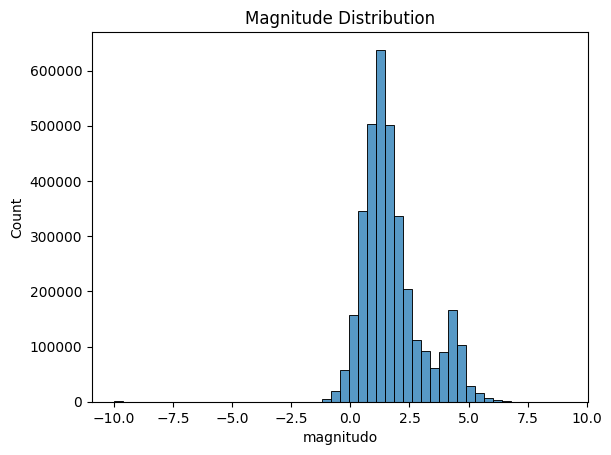

Sampled shape: (344575, 12)


,time,place,status,tsunami,significance,data_type,magnitudo,state,longitude,latitude,depth,date
1699008,1276872091100,"7km ESE of Ocotillo, CA",reviewed,0,34,earthquake,1.48,California,-115.921000,32.707333,3.136,2010-06-18 14:41:31.100000+00:00
24039,643482190580,"1 km SW of Jamestown, California",reviewed,0,33,quarry blast,1.47,California,-120.434333,37.942333,-0.485,1990-05-23 17:03:10.580000+00:00
2681076,1535245296582,"74 km SSW of Kaktovik, Alaska",reviewed,0,89,earthquake,2.40,Alaska,-144.346400,69.516600,8.300,2018-08-26 01:01:36.582000+00:00
249359,750576925450,"27km N of Yucca Valley, California",reviewed,0,44,earthquake,1.69,California,-116.462000,34.352000,3.736,1993-10-14 05:35:25.450000+00:00
2938561,1587524197348,"32 km NNE of Whittier, Alaska",reviewed,0,26,ice quake,1.30,Alaska,-148.451900,61.043800,0.000,2020-04-22 02:56:37.348000+00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ZIP_PATH = "/content/drive/MyDrive/archive.zip"
DATA_DIR = Path("/content/data")
DATA_DIR.mkdir(exist_ok=True)

import zipfile
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(DATA_DIR)

df = pd.read_csv(DATA_DIR / "Eartquakes-1990-2023.csv")

print(f"Dataset shape: {df.shape}")
print("\nSummary Statistics:")
display(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nMagnitude Distribution:")
sns.histplot(df['magnitudo'], bins=50)
plt.title("Magnitude Distribution")
plt.show()

# Sample 10% for faster processing
df = df.sample(frac=0.1, random_state=42)
print(f"Sampled shape: {df.shape}")
df.head()

## 3. Feature Engineering

We derive temporal and geospatial features to enhance model performance. Magnitude is binned into classes, and logarithmic transformation is applied to depth for skewness handling.

In [ ]:
def robust_preprocess(df):
    df = df.copy()

    # Datetime features
    df['datetime'] = pd.to_datetime(df['date'], errors='coerce')
    df['year'] = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    df['day'] = df['datetime'].dt.day
    df['hour'] = df['datetime'].dt.hour

    # Magnitude classification
    bins = [0, 4.0, 5.0, 6.0, 7.0, np.inf]
    labels = ['Minor', 'Light', 'Moderate', 'Strong', 'Major']
    df['magnitude_class'] = pd.cut(df['magnitudo'], bins=bins, labels=labels)

    le = LabelEncoder()
    df['magnitude_encoded'] = le.fit_transform(df['magnitude_class'])

    # Additional features
    df['depth'] = df['depth'].clip(lower=0)  # Handle negative depths
    df['depth_log'] = np.log1p(df['depth'])
    df['lat_bin'] = pd.cut(df['latitude'], bins=20)
    df['lon_bin'] = pd.cut(df['longitude'], bins=20)
    df['season'] = df['month'].map({1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',6:'Summer',7:'Summer',8:'Summer',9:'Fall',10:'Fall',11:'Fall',12:'Winter'})
    df['is_deep'] = (df['depth'] > 70).astype(int)
    df['near_plate_boundary'] = ((abs(df['latitude']) > 20) & (abs(df['longitude']) < 50)).astype(int)

    FEATURES = ['latitude', 'longitude', 'depth', 'year', 'month', 'day', 'hour', 'depth_log', 'lat_bin', 'lon_bin', 'season', 'is_deep', 'near_plate_boundary']
    CAT_FEATURES = ['lat_bin', 'lon_bin', 'season']
    NUM_FEATURES = [c for c in FEATURES if c not in CAT_FEATURES]

    df = df.dropna(subset=FEATURES + ['magnitude_encoded'])
    return df, le, FEATURES, CAT_FEATURES, NUM_FEATURES

df, le, FEATURES, CAT_FEATURES, NUM_FEATURES = robust_preprocess(df)
CLASS_NAMES = le.classes_

print(f"Using {len(FEATURES)} features")
print("Class Distribution After Processing:")
print(df['magnitude_class'].value_counts())

Using 13 features
Class Distribution After Processing:
magnitude_class
Minor       293655
Light        30789
Moderate      3883
Strong         358
Major           38
Name: count, dtype: int64


## 4. Model Selection & Hyperparameter Tuning

We evaluate XGBoost and LightGBM, two top-performing gradient boosting frameworks. Hyperparameters are optimized using Optuna with 10 trials each for efficiency. We use CPU-optimized methods for compatibility.

In [ ]:
X = df[FEATURES]
y = df['magnitude_encoded']

# Filter rare classes to avoid stratification issues
class_counts = y.value_counts()
rare_classes = class_counts[class_counts < 5].index
X = X[~y.isin(rare_classes)]
y = y[~y.isin(rare_classes)]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

preprocess = ColumnTransformer([
    ('num', StandardScaler(), NUM_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATURES)
])

def tune_model(model_type):
    def objective(trial):
        if model_type == 'xgb':
            params = {
                'n_estimators': trial.suggest_int('n_est', 500, 1500),
                'max_depth': trial.suggest_int('depth', 4, 10),
                'learning_rate': trial.suggest_float('lr', 0.005, 0.1, log=True),
                'subsample': trial.suggest_float('sub', 0.6, 1.0),
                'tree_method': 'hist',  # CPU-optimized
                'random_state': 42
            }
            model = XGBClassifier(**params)
        elif model_type == 'lgb':
            params = {
                'n_estimators': trial.suggest_int('n_est', 500, 1500),
                'max_depth': trial.suggest_int('depth', 4, 10),
                'learning_rate': trial.suggest_float('lr', 0.005, 0.1, log=True),
                'num_leaves': trial.suggest_int('leaves', 20, 100),
                'random_state': 42
            }
            model = LGBMClassifier(**params)

        pipe = Pipeline([('prep', preprocess), ('model', model)])
        score = cross_val_score(pipe, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1).mean()
        return score

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=10)  # Reduced for speed
    return study.best_params, study.best_value

print("Tuning XGBoost...")
xgb_params, xgb_score = tune_model('xgb')
print(f"XGBoost Best CV Score: {xgb_score:.4f}")

print("Tuning LightGBM...")
lgb_params, lgb_score = tune_model('lgb')
print(f"LightGBM Best CV Score: {lgb_score:.4f}")

[I 2026-01-07 10:08:22,390] A new study created in memory with name: no-name-b1eb5842-05be-479c-b5a4-f090fa440f91


Tuning XGBoost...


[I 2026-01-07 10:10:03,414] Trial 0 finished with value: 0.9391463581993911 and parameters: {'n_est': 893, 'depth': 4, 'lr': 0.017577908322287186, 'sub': 0.80470512913812}. Best is trial 0 with value: 0.9391463581993911.
[I 2026-01-07 10:11:38,870] Trial 1 finished with value: 0.941565796701676 and parameters: {'n_est': 678, 'depth': 6, 'lr': 0.06889112688665112, 'sub': 0.6907028066680803}. Best is trial 1 with value: 0.941565796701676.
[I 2026-01-07 10:13:25,398] Trial 2 finished with value: 0.9402788608008378 and parameters: {'n_est': 863, 'depth': 6, 'lr': 0.0107762285455279, 'sub': 0.9962972580778063}. Best is trial 1 with value: 0.941565796701676.
[I 2026-01-07 10:15:56,561] Trial 3 finished with value: 0.9390470807188329 and parameters: {'n_est': 1417, 'depth': 4, 'lr': 0.010641845146635347, 'sub': 0.7641962021438159}. Best is trial 1 with value: 0.941565796701676.
[I 2026-01-07 10:18:18,417] Trial 4 finished with value: 0.9415363812330014 and parameters: {'n_est': 1067, 'depth':

XGBoost Best CV Score: 0.9421
Tuning LightGBM...


[I 2026-01-07 10:34:21,786] Trial 0 finished with value: 0.9404185850679658 and parameters: {'n_est': 790, 'depth': 5, 'lr': 0.04765363842315537, 'leaves': 57}. Best is trial 0 with value: 0.9404185850679658.
[I 2026-01-07 10:38:58,822] Trial 1 finished with value: 0.9400803027571468 and parameters: {'n_est': 1389, 'depth': 8, 'lr': 0.026575358910188952, 'leaves': 80}. Best is trial 0 with value: 0.9404185850679658.
[I 2026-01-07 10:43:32,939] Trial 2 finished with value: 0.9209638086140514 and parameters: {'n_est': 1470, 'depth': 10, 'lr': 0.0791429486226782, 'leaves': 53}. Best is trial 0 with value: 0.9404185850679658.
[I 2026-01-07 10:45:26,965] Trial 3 finished with value: 0.9401501719887446 and parameters: {'n_est': 833, 'depth': 6, 'lr': 0.035983050977426434, 'leaves': 85}. Best is trial 0 with value: 0.9404185850679658.
[I 2026-01-07 10:46:36,343] Trial 4 finished with value: 0.9406061103741546 and parameters: {'n_est': 770, 'depth': 4, 'lr': 0.03576539260453169, 'leaves': 69}.

LightGBM Best CV Score: 0.9408


## 5. Model Comparison & Selection

We compare the tuned models based on cross-validation accuracy, precision, recall, and F1-score. The best model is selected for final training and deployment.

In [ ]:
# Train and evaluate each
def evaluate_model(model, name):
    pipe = Pipeline([('prep', preprocess), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=CLASS_NAMES, output_dict=True)
    print(f"{name} Test Accuracy: {acc:.4f}")
    return pipe, acc, report

xgb_model = XGBClassifier(**xgb_params, tree_method='hist')
xgb_pipe, xgb_acc, xgb_report = evaluate_model(xgb_model, 'XGBoost')

lgb_model = LGBMClassifier(**lgb_params)
lgb_pipe, lgb_acc, lgb_report = evaluate_model(lgb_model, 'LightGBM')

# Select best
best_model = xgb_pipe if xgb_acc > lgb_acc else lgb_pipe
best_name = 'XGBoost' if xgb_acc > lgb_acc else 'LightGBM'
print(f"\nSelected Best Model: {best_name} with Accuracy {max(xgb_acc, lgb_acc):.4f}")

# Final CV on full data
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='accuracy')
print(f"Final CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Save best model
ARTIFACTS_DIR = Path("/content/drive/MyDrive/EarthquakePred")
ARTIFACTS_DIR.mkdir(exist_ok=True)
joblib.dump(best_model, ARTIFACTS_DIR / "best_model.pkl")
joblib.dump(le, ARTIFACTS_DIR / "label_encoder.pkl")
joblib.dump(FEATURES, ARTIFACTS_DIR / "features.pkl")
print("Best model saved!")

XGBoost Test Accuracy: 0.9422
[LightGBM] [Warning] Unknown parameter: leaves
[LightGBM] [Warning] Unknown parameter: depth
[LightGBM] [Warning] Unknown parameter: n_est
[LightGBM] [Warning] Unknown parameter: lr
[LightGBM] [Warning] Unknown parameter: leaves
[LightGBM] [Warning] Unknown parameter: depth
[LightGBM] [Warning] Unknown parameter: n_est
[LightGBM] [Warning] Unknown parameter: lr
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006301 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1214
[LightGBM] [Info] Number of data points in the train set: 271964, number of used features: 52
[LightGBM] [Info] Start training from score -2.401664
[LightGBM] [Info] Start training from score -9.112228
[LightGBM] [Info] Start training from score -0.146408
[LightGBM] [Info] Start training from score -4.472012
[LightGBM] [Info] Start training fro

## 6. Model Evaluation & Interpretability

We assess the selected model using confusion matrices and SHAP values for local and global interpretability.

In [ ]:
# Code cell for saving models' performance as CSV and necessary plots as PNG

import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import shap
import matplotlib.pyplot as plt

# Define PLOTS_DIR as it was not defined in the provided notebook state
PLOTS_DIR = ARTIFACTS_DIR / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

# Function to convert classification report to DataFrame
def report_to_df(report, model_name):
    rows = []
    for cls, metrics in report.items():
        if cls not in ['accuracy', 'macro avg', 'weighted avg']:
            rows.append({
                'model': model_name,
                'class': cls,
                'precision': metrics['precision'],
                'recall': metrics['recall'],
                'f1': metrics['f1-score'],
                'support': metrics['support']
            })
    return pd.DataFrame(rows)

# Collect performances
xgb_df = report_to_df(xgb_report, 'XGBoost')
lgb_df = report_to_df(lgb_report, 'LightGBM')
perf_df = pd.concat([xgb_df, lgb_df])

# Save to CSV
perf_df.to_csv(ARTIFACTS_DIR / "models_performance.csv", index=False)
print("Models performance saved to CSV!")

# Function to save confusion matrix and SHAP summary for a model
def save_plots(pipe, name, X_test_sample, y_test_sample):
    y_pred = pipe.predict(X_test_sample)
    cm = confusion_matrix(y_test_sample, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))

    # Dynamically get display labels from the unique classes in the sample
    unique_true_labels = np.unique(y_test_sample)
    display_labels_for_plot = le.inverse_transform(unique_true_labels)

    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels_for_plot).plot(ax=ax, cmap=plt.cm.Blues)
    plt.title(f"{name} Confusion Matrix")
    plt.savefig(PLOTS_DIR / f"{name}_confusion_matrix.png", dpi=300, bbox_inches='tight')
    plt.close()

    # SHAP
    X_proc = pipe.named_steps['prep'].transform(X_test_sample)
    explainer = shap.TreeExplainer(pipe.named_steps['model'])
    shap_values = explainer.shap_values(X_proc)
    fig = plt.figure(figsize=(8, 6))
    shap.summary_plot(shap_values, X_proc, feature_names=pipe.named_steps['prep'].get_feature_names_out(), show=False)
    plt.savefig(PLOTS_DIR / f"{name}_shap_summary.png", dpi=300, bbox_inches='tight')
    plt.close()

# Save plots for both models (using a sample for SHAP efficiency)
X_test_sample = X_test.sample(100, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

save_plots(xgb_pipe, 'XGBoost', X_test_sample, y_test_sample)
save_plots(lgb_pipe, 'LightGBM', X_test_sample, y_test_sample)
print("Necessary plots saved as PNG!")

Models performance saved to CSV!
[LightGBM] [Warning] Unknown parameter: leaves
[LightGBM] [Warning] Unknown parameter: depth
[LightGBM] [Warning] Unknown parameter: lr
[LightGBM] [Warning] Unknown parameter: n_est
Necessary plots saved as PNG!


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [ ]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
from google.colab import drive
import gradio as gr
import shap
import matplotlib.pyplot as plt
from datetime import datetime
from PIL import Image
import io
import warnings
import folium

# Suppress warnings
warnings.filterwarnings("ignore")

# Mount Drive
drive.mount('/content/drive')

# Artifacts path
ARTIFACTS_DIR = Path("/content/drive/MyDrive/EarthquakePred")

# Load artifacts
best_model = joblib.load(ARTIFACTS_DIR / "best_model.pkl")
le = joblib.load(ARTIFACTS_DIR / "label_encoder.pkl")
FEATURES = joblib.load(ARTIFACTS_DIR / "features.pkl")
CLASS_NAMES = le.classes_
LAT_BINS = np.linspace(-90, 90, 21)
LON_BINS = np.linspace(-180, 180, 21)
bin_labels = [f'lat_bin_{i}' for i in range(20)]
lat_labels = [f'lat_bin_{i}' for i in range(20)]
lon_labels = [f'lon_bin_{i}' for i in range(20)]

# Color map
COLOR_MAP = {
    'Minor': 'green',
    'Light': 'lightgreen',
    'Moderate': 'orange',
    'Strong': 'red',
    'Major': 'darkred'
}

def predict_magnitude(latitude: float, longitude: float, depth: float, date_time_str: str):
    try:
        input_data = pd.DataFrame({
            'latitude': [latitude],
            'longitude': [longitude],
            'depth': [max(0, depth)],
            'date': [date_time_str]
        })

        input_data['datetime'] = pd.to_datetime(input_data['date'], errors='coerce')
        if pd.isna(input_data['datetime'].iloc[0]):
            raise ValueError("Invalid date format")

        input_data['year'] = input_data['datetime'].dt.year
        input_data['month'] = input_data['datetime'].dt.month
        input_data['day'] = input_data['datetime'].dt.day
        input_data['hour'] = input_data['datetime'].dt.hour

        input_data['depth_log'] = np.log1p(input_data['depth'])

        # EXACTLY match original training binning
        input_data['lat_bin'] = pd.cut(input_data['latitude'], bins=LAT_BINS, include_lowest=True, right=True, labels=lat_labels)
        input_data['lon_bin'] = pd.cut(input_data['longitude'], bins=LON_BINS, include_lowest=True, right=True, labels=lon_labels)

        season_map = {1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
                      6:'Summer',7:'Summer',8:'Summer',9:'Fall',10:'Fall',11:'Fall',12:'Winter'}
        input_data['season'] = input_data['month'].map(season_map)
        input_data['is_deep'] = (input_data['depth'] > 70).astype(int)
        input_data['near_plate_boundary'] = ((abs(input_data['latitude']) > 20) & (abs(input_data['longitude']) < 50)).astype(int)

        X_input = input_data[FEATURES]

        # Prediction
        pred_idx = best_model.predict(X_input)[0]
        predicted_class = le.inverse_transform([pred_idx])[0]

        probs = best_model.predict_proba(X_input)[0]
        probability_dict = {CLASS_NAMES[i]: float(probs[i]) for i in range(len(CLASS_NAMES))}

        # === SHAP WATERFALL FOR MULTI-CLASS ===
        X_processed = best_model.named_steps['prep'].transform(X_input)  # shape (1, n_features)
        feature_names = best_model.named_steps['prep'].get_feature_names_out()

        explainer = shap.TreeExplainer(best_model.named_steps['model'])
        shap_values = explainer.shap_values(X_processed)  # list of arrays, one per class

        # shap_values[pred_idx] is the SHAP values for the predicted class
        shap_for_pred_class = shap_values[pred_idx]  # shape (1, n_features)

        # Create Explanation object for the single instance and predicted class
        explanation = shap.Explanation(
            values=shap_for_pred_class[0],
            base_values=explainer.expected_value[pred_idx],
            data=X_processed[0],
            feature_names=feature_names
        )

        plt.figure(figsize=(8, 6))
        shap.waterfall_plot(explanation, max_display=12, show=False)
        plt.tight_layout()

        buf = io.BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight', dpi=150)
        plt.close()
        buf.seek(0)
        shap_img = Image.open(buf)

        # Interactive Map
        m = folium.Map(location=[latitude, longitude], zoom_start=7, tiles="OpenStreetMap")
        color = COLOR_MAP.get(predicted_class, 'blue')
        folium.CircleMarker(
            location=[latitude, longitude],
            radius=20,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.8,
            popup=folium.Popup(f"<b>Predicted: {predicted_class}</b><br>Depth: {depth} km<br>{date_time_str}", max_width=300)
        ).add_to(m)

        map_html = m._repr_html_()

        return predicted_class, probability_dict, shap_img, map_html

    except Exception as e:
        return f"Error: {str(e)}", {}, None, "<p>Something went wrong. Check inputs.</p>"

# Gradio App
with gr.Blocks(theme=gr.themes.Soft()) as app:
    gr.Markdown("# 🌍 AI-Powered Earthquake Magnitude Prediction")
    gr.Markdown("Enter location, depth & time → Get prediction, probabilities, SHAP explanation & interactive map!")

    with gr.Row():
        with gr.Column(scale=1):
            lat = gr.Slider(-90, 90, value=34.05, step=0.01, label="Latitude")
            lon = gr.Slider(-180, 180, value=-118.25, step=0.01, label="Longitude")
            depth = gr.Slider(0, 700, value=10, step=1, label="Depth (km)")
            dt = gr.Textbox(label="Date & Time (YYYY-MM-DD HH:MM:SS)", value="2026-01-07 10:30:00")

            gr.Examples(
                examples=[
                    [-38.145, -73.03, 40, "2026-01-07 08:20:00"],
                ],
                inputs=[lat, lon, depth, dt]
            )

        with gr.Column(scale=1):
            pred = gr.Textbox(label="Predicted Magnitude Class", interactive=False)
            probs = gr.Label(label="Class Probabilities")

            with gr.Tabs():
                with gr.Tab("SHAP Explanation"):
                    shap_out = gr.Image(label="Feature Importance for Prediction")
                with gr.Tab("Location Map"):
                    map_out = gr.HTML(label="Interactive Map")

    gr.Markdown("**Magnitude Classes**: Minor (green) • Light (lightgreen) • Moderate (orange) • Strong (red) • Major (darkred)")

    gr.Button("Predict").click(
        fn=predict_magnitude,
        inputs=[lat, lon, depth, dt],
        outputs=[pred, probs, shap_out, map_out]
    )

app.launch(debug=True, share=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://a89af8e8462acb8e17.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://a89af8e8462acb8e17.gradio.live
